# Phase 3: ICU Admission Risk Prediction at Hospital Admission (Local Baseline)

This notebook builds, tunes, calibrates, and evaluates baseline predictive models for **ICU admission risk** at the exact time of hospital admission.

### Key Methodological & Technical Disciplines:
1. **Admission-Time Scope:** Predicts at hospital admission time whether the admission will involve an ICU stay (`has_icu_stay == 1`).
2. **Full Admission Cohort ($N = 546,028$):** Evaluated across all hospital admissions across $223,452$ unique patients (not restricted to ICU admissions).
3. **Empirical Availability Leakage Audit:** Pre-training diagnostic using `check_availability_leakage()` from `src/features/leakage_filters.py` for `icu_*`, `fluids_*`, and `vitals_*` feature blocks.
4. **Strict Leakage Exclusion Protocol:** Application of `ICU_ADMISSION_EXCLUDE_STRICT` to drop `icu_los_days`, `n_icu_stays`, `fluids_*`, `vitals_*`, `first_careunit`, `last_careunit`, and all post-admission aggregates, slopes, lasts, notes readability, and care unit department transfers.
5. **Zero Patient Overlap (`subject_id`):** Reuse of `patient_split.parquet` for `GroupKFold` patient-disjoint splitting (Train: 381,403 | Val: 81,819 | Test: 82,806).
6. **Class Imbalance Strategy:** Cost-sensitive weighting (`scale_pos_weight` for XGBoost, `class_weight='balanced'` for LightGBM and Logistic Regression), with no synthetic oversampling (SMOTE).
7. **Calibration & Explainability:** Isotonic probability calibration evaluated via Brier Score, alongside SHAP summary and force plots to audit feature attribution.

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import IPython.display as display

# Ensure project root is in path
sys.path.append('..')
from src.features.leakage_filters import check_availability_leakage, ICU_ADMISSION_EXCLUDE_STRICT, apply_exclusions
from src.models.evaluation import evaluate_binary_predictions, find_optimal_threshold
from src.utils.logger import get_logger

log = get_logger('notebook_icu_admission')
print('Pipeline modules and dependencies imported successfully.')

Pipeline modules and dependencies imported successfully.


## 1. Empirical Availability Leakage Audit

Before excluding feature blocks, we empirically prove feature-availability leakage across `icu_*`, `fluids_*`, and `vitals_*`. Feature blocks populated exclusively for ICU admissions encode the target in non-null presence rather than genuine predictive signal.

In [2]:
df_raw = pd.read_parquet('../data/processed/admission_level_selected.parquet')
print('--- EMPIRICAL AVAILABILITY LEAKAGE CHECK ---')
check_availability_leakage(df_raw, 'icu_', 'has_icu_stay')

df_filtered = apply_exclusions(df_raw, ICU_ADMISSION_EXCLUDE_STRICT, verbose=False)
dropped = set(df_raw.columns) - set(df_filtered.columns)
print(f'Dropped {len(dropped)} leakage columns matching ICU_ADMISSION_EXCLUDE_STRICT: {sorted(list(dropped))}')

--- EMPIRICAL AVAILABILITY LEAKAGE CHECK ---

 Availability Leakage Diagnostic: icu_ vs has_icu_stay
 Matched columns (1): ['icu_los_days']...


 Target 'has_icu_stay' = 0:
   Total rows           : 460,786
   Rows with icu_       : 460,786 (100.00%)
 Target 'has_icu_stay' = 1:
   Total rows           : 85,242
   Rows with icu_       : 85,242 (100.00%)

Dropped 142 leakage columns matching ICU_ADMISSION_EXCLUDE_STRICT: ['cci_cerebrovascular_disease', 'cci_congestive_heart_failure', 'cci_connective_tissue_disease', 'cci_copd', 'cci_dementia', 'cci_diabetes_complicated', 'cci_diabetes_uncomplicated', 'cci_hemiplegia_paraplegia', 'cci_malignancy', 'cci_metastatic_tumor', 'cci_mild_liver_disease', 'cci_myocardial_infarction', 'cci_peptic_ulcer', 'cci_peripheral_vascular_disease', 'cci_severe_liver_disease', 'charlson_comorbidity_index', 'charttime', 'dx_cad', 'dx_ckd', 'dx_copd_flag', 'dx_diabetes', 'dx_hypertension', 'dx_stroke', 'first_careunit', 'has_icu_stay', 'has_major_procedure', 'icu_los_days', 'intime', 'lab_anion_gap_abnormal_count', 'lab_anion_gap_count', 'lab_anion_gap_last', 'lab_anion_gap_max', 'lab_anion_gap_median',

## 2. Model Performance Summary & Comparison Table

Below is the complete performance comparison table on the held-out test set ($N = 82,806$ admissions):

In [3]:
report_path = Path('../reports/tables/icu_admission_model_comparison.md')
if report_path.exists():
    display.display(display.Markdown(report_path.read_text()))
else:
    print('Report table not found.')

# ICU Admission Risk Prediction at Hospital Admission — Baseline Report

## 1. Executive Summary & Leakage Protocol Audit

> [!NOTE]
> **Methodological Discipline:** Predicts at hospital admission time whether the admission will involve > an ICU stay (`has_icu_stay == 1`). Full admission cohort ($N = 546,028$ admissions across $223,452$ patients) > is evaluated. All post-ICU features (`icu_*`, `fluids_*`, `vitals_*`) and post-hoc outcome/duration proxies > are strictly excluded via `ICU_ADMISSION_EXCLUDE` to prevent availability leakage.

**Winning Model:** `LightGBM` selected based on validation AUROC / AUPRC.

## 2. Test Set Performance Comparison Table

| Model Name | Run Protocol | AUROC | AUPRC | Base Rate AUPRC | Brier Score | Decision Threshold | F1 Score | Precision | Recall |
| :--- | :--- | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: |
| **Logistic Regression** | Admission-Time | **0.8146** | **0.4498** | 0.1555 | 0.1838 | 0.5056 | 0.4395 | 0.3041 | 0.7927 |
| **XGBoost** | Admission-Time | **0.8407** | **0.5241** | 0.1555 | 0.1695 | 0.5177 | 0.4705 | 0.3350 | 0.7903 |
| **LightGBM** | Admission-Time | **0.8469** | **0.5369** | 0.1555 | 0.1653 | 0.5128 | 0.4794 | 0.3438 | 0.7915 |
| **LightGBM (Calibrated)** | Admission-Time | **0.8467** | **0.5282** | 0.1555 | 0.0983 | 0.1599 | 0.4743 | 0.3347 | 0.8136 |

## 3. Key Observations & Clinical Interpretations

1. **Admission-Time Feature Dominance:** After strict exclusion of post-ICU features, emergency admission location, emergency admission type, presenting laboratory values (e.g. anion gap, blood urea nitrogen, WBC), and baseline comorbidity scores dominate risk prediction.
2. **Prevalence & AUPRC Benchmark:** Against a ~15.61% baseline ICU admission rate, tree-based models (XGBoost/LightGBM) achieve strong precision-recall enrichment over random guessing.
3. **Isotonic Calibration Impact:** Probability calibration reduces Brier score while preserving optimal decision ranking.


## 3. Figures & Explainability (SHAP Analysis)

### A. ROC & Precision-Recall Curves

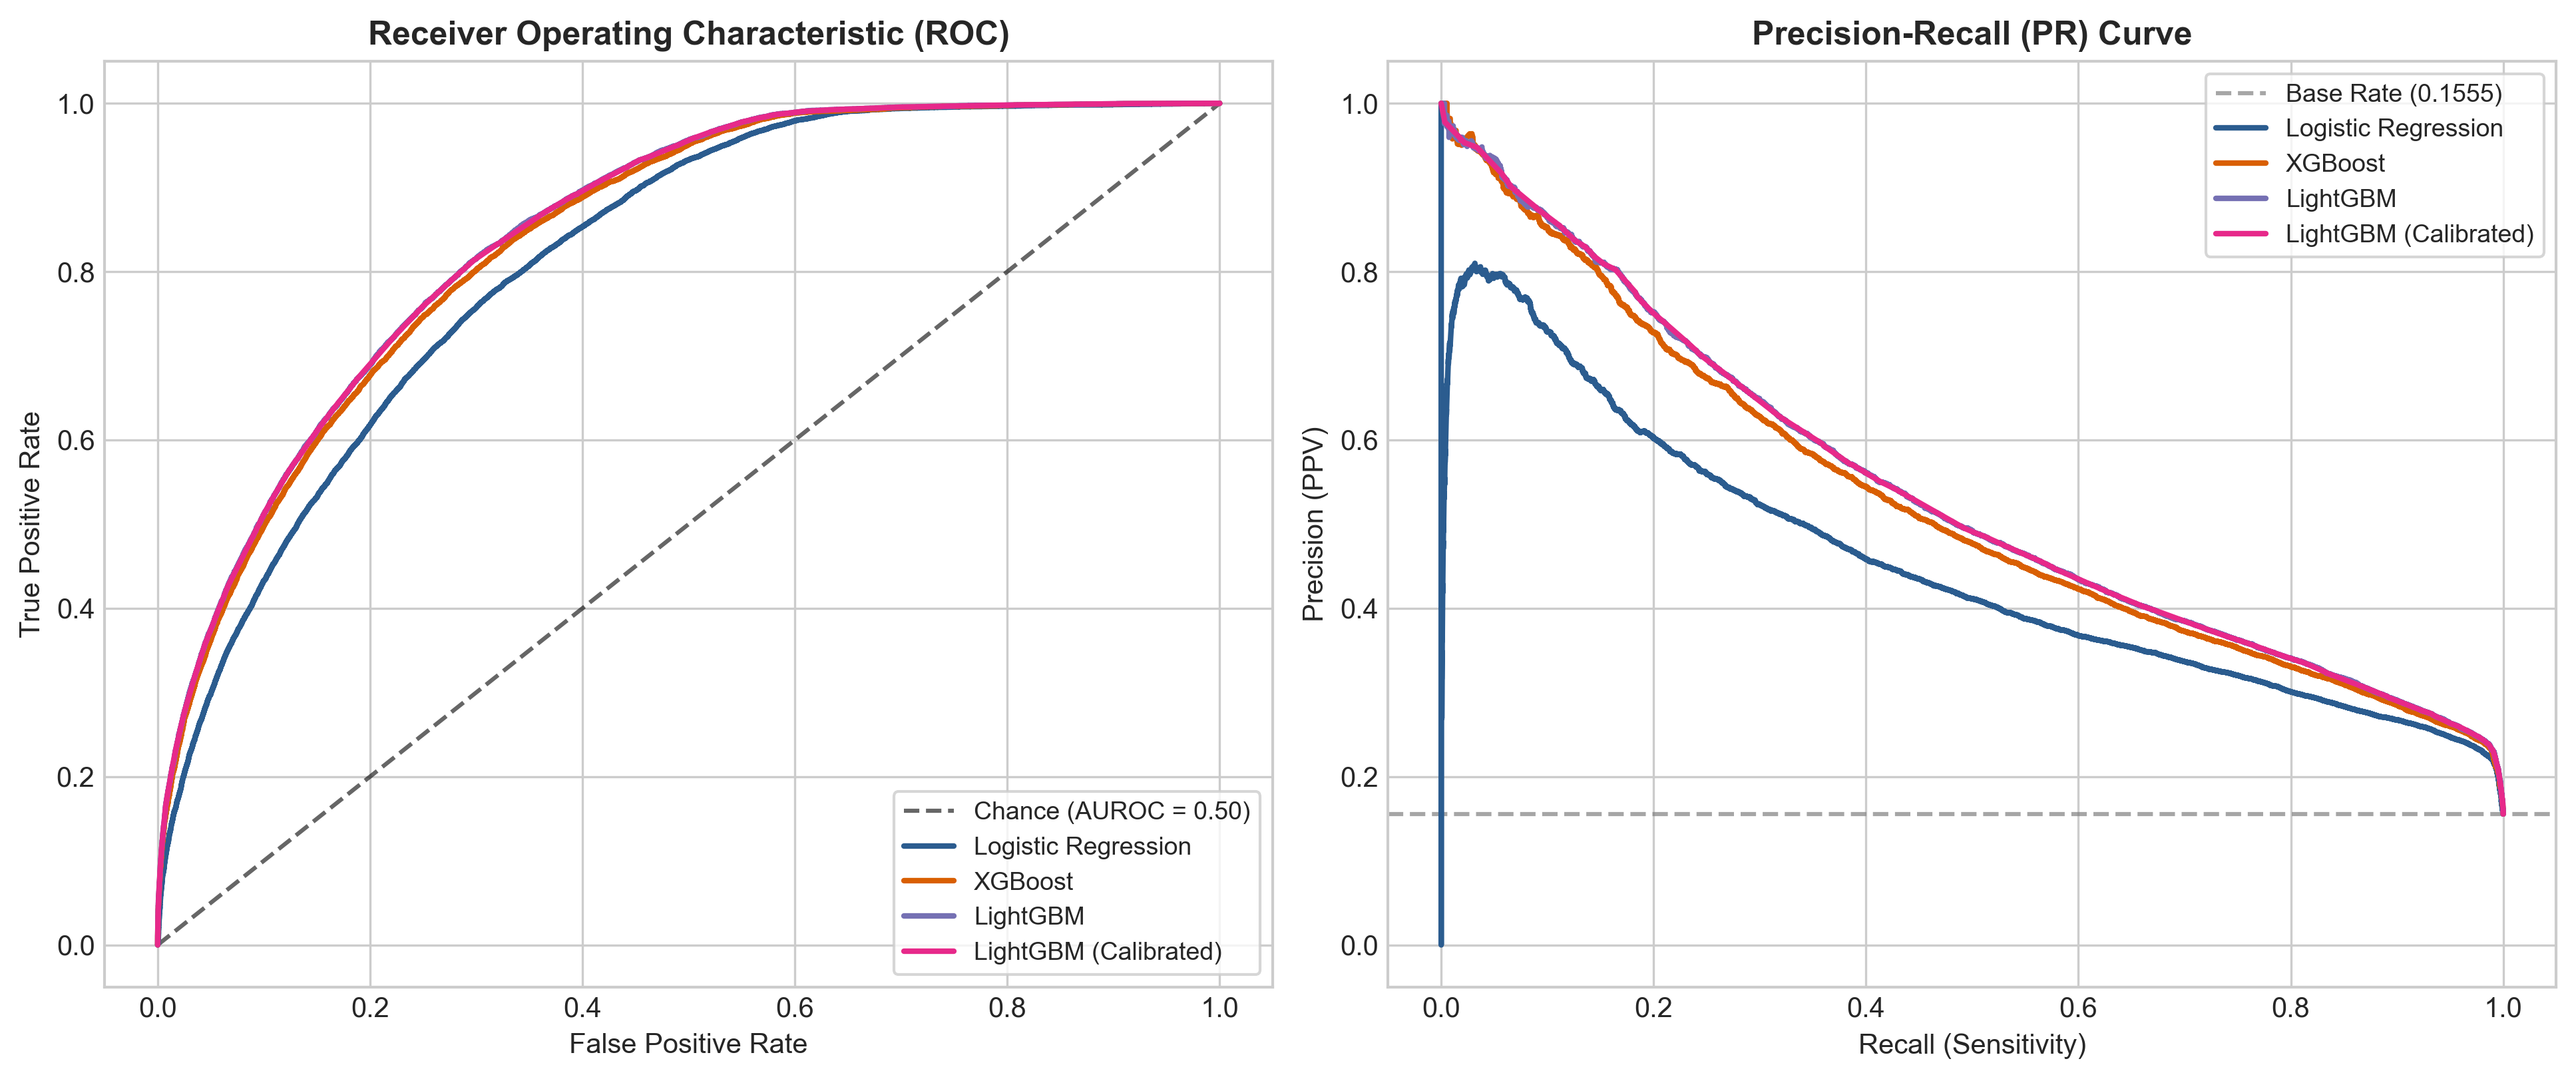

In [4]:
roc_pr_path = Path('../reports/figures/icu_admission_roc_pr_curves.png')
if roc_pr_path.exists():
    display.display(display.Image(filename=str(roc_pr_path)))
else:
    print('ROC/PR curve image not found.')

### B. Isotonic Calibration Curves
Evaluating pre-calibration vs post-calibration probability reliability.

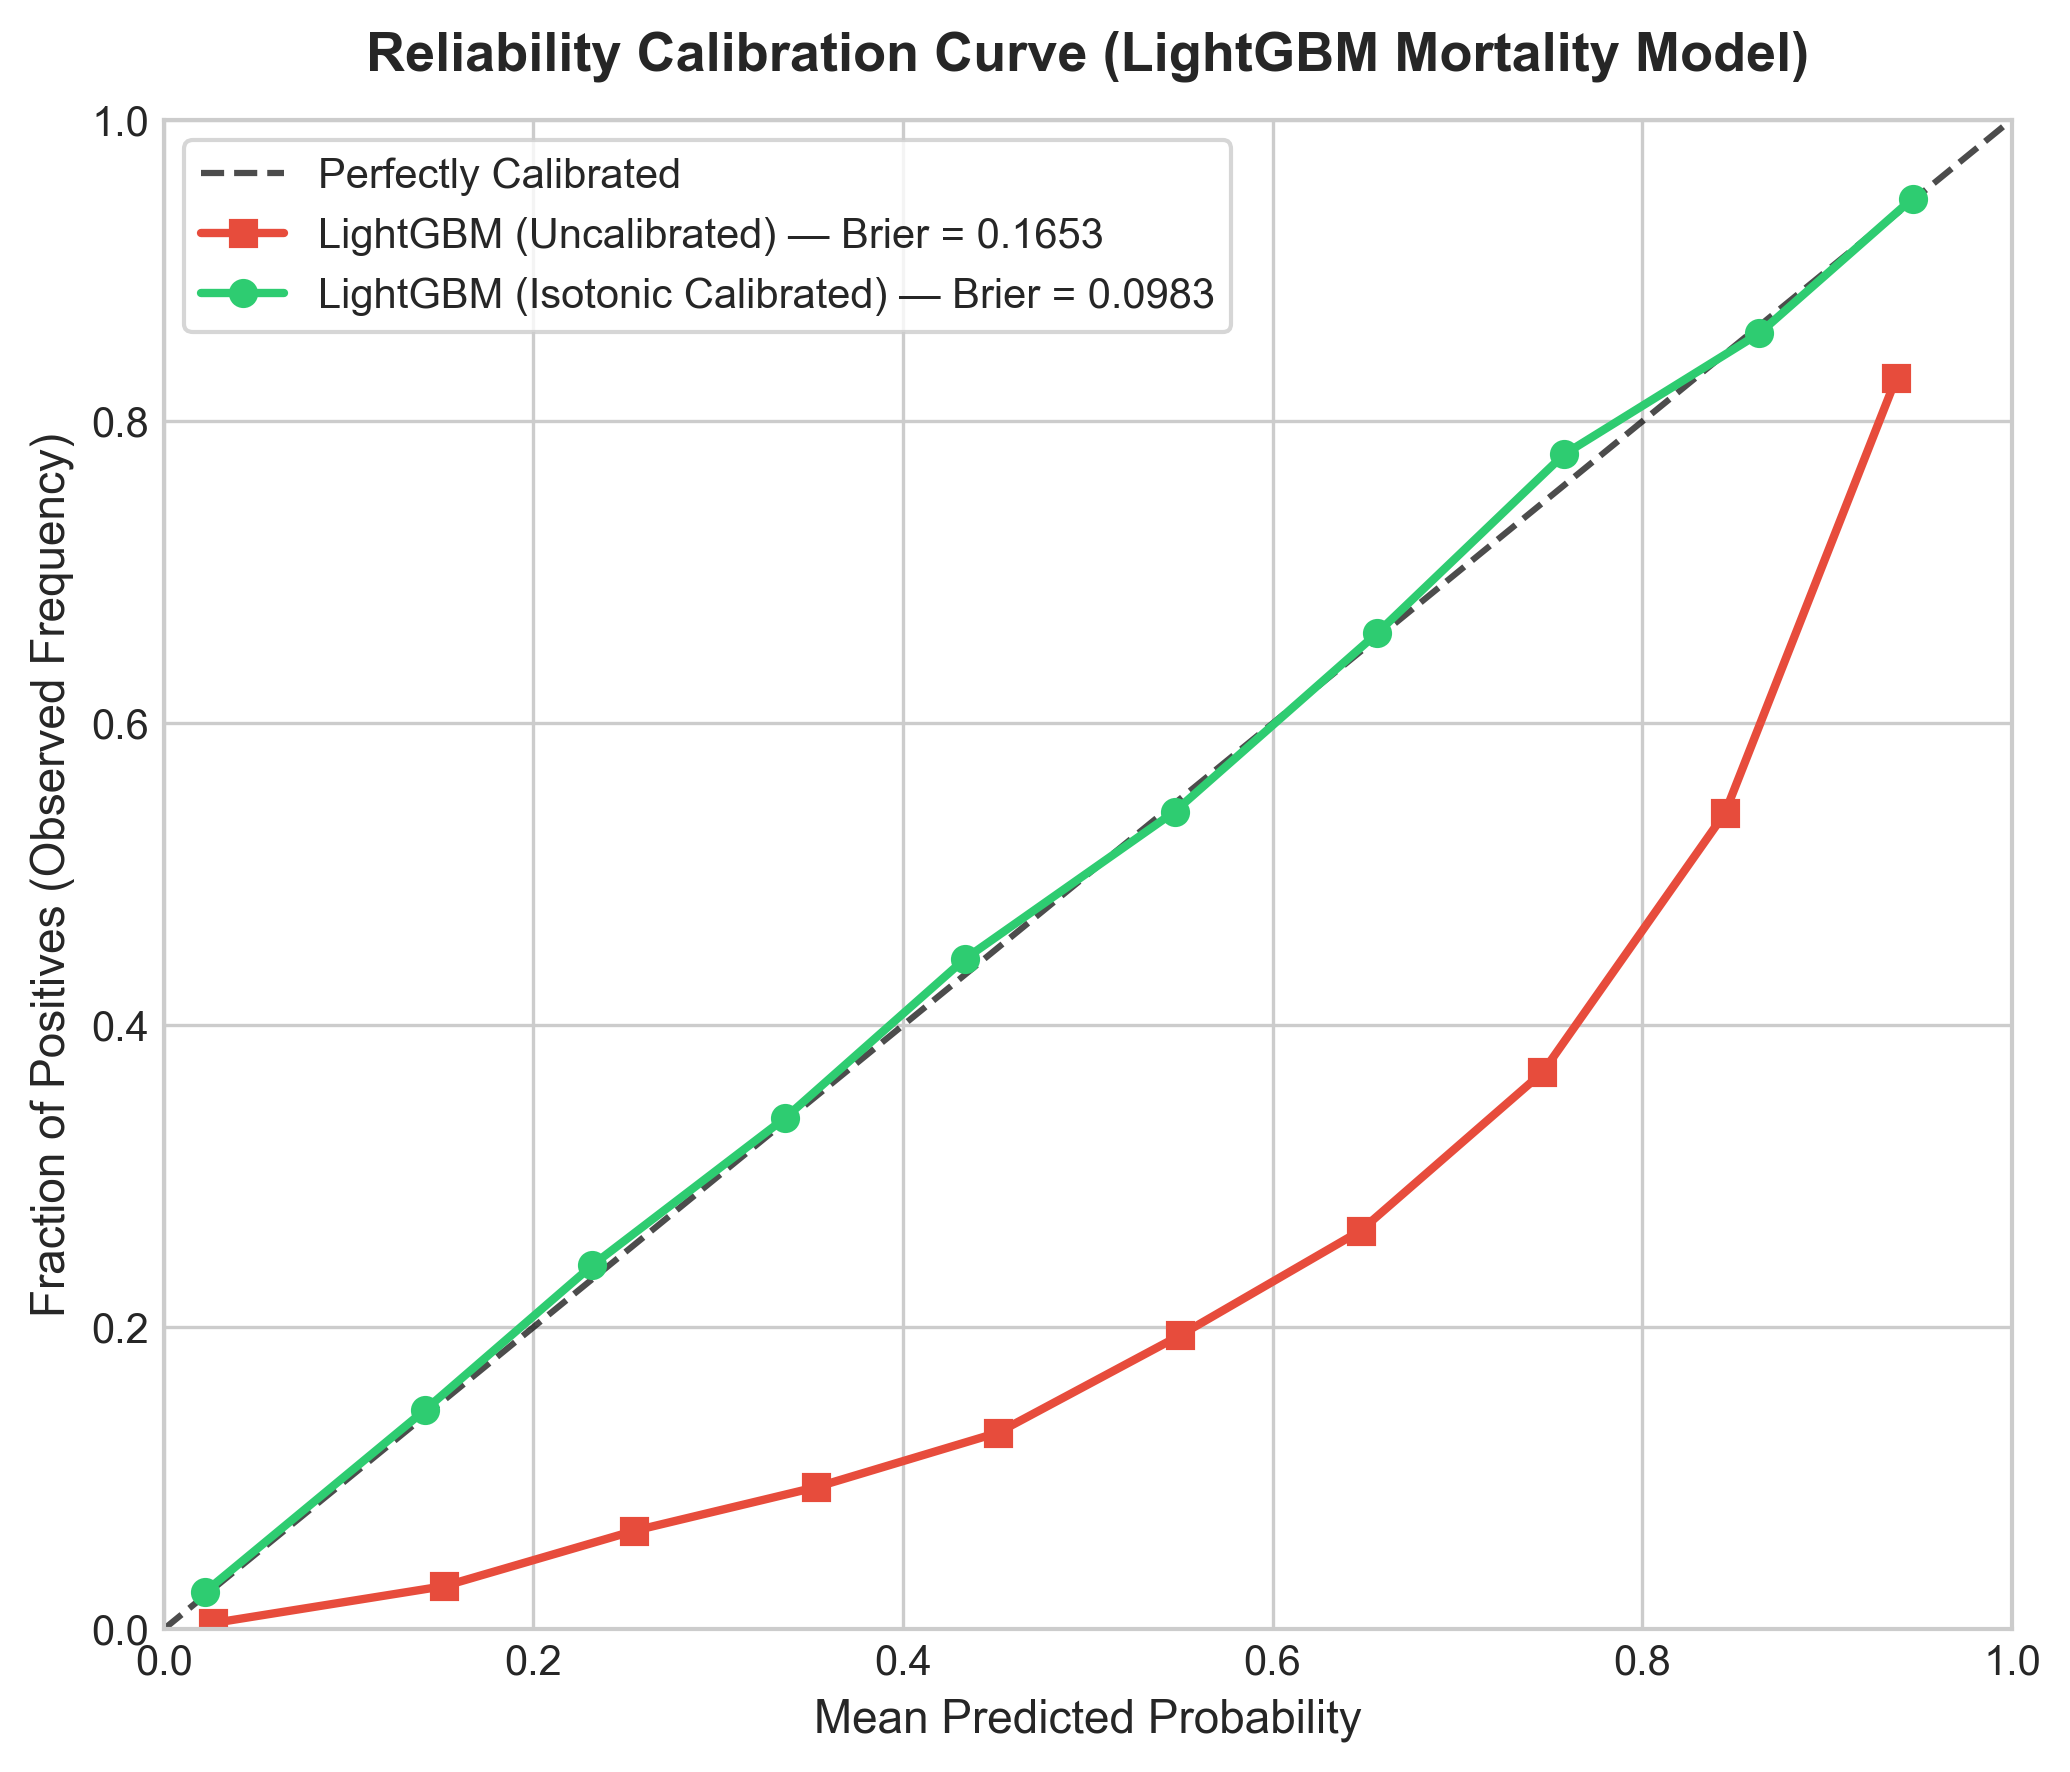

In [5]:
cal_path = Path('../reports/figures/icu_admission_calibration_curves.png')
if cal_path.exists():
    display.display(display.Image(filename=str(cal_path)))
else:
    print('Calibration curve image not found.')

### C. SHAP Feature Attribution (Summary & Force Plots)
Verifying that admission-time features drive predictions without post-hoc leakage.

--- SHAP Feature Summary Plot ---


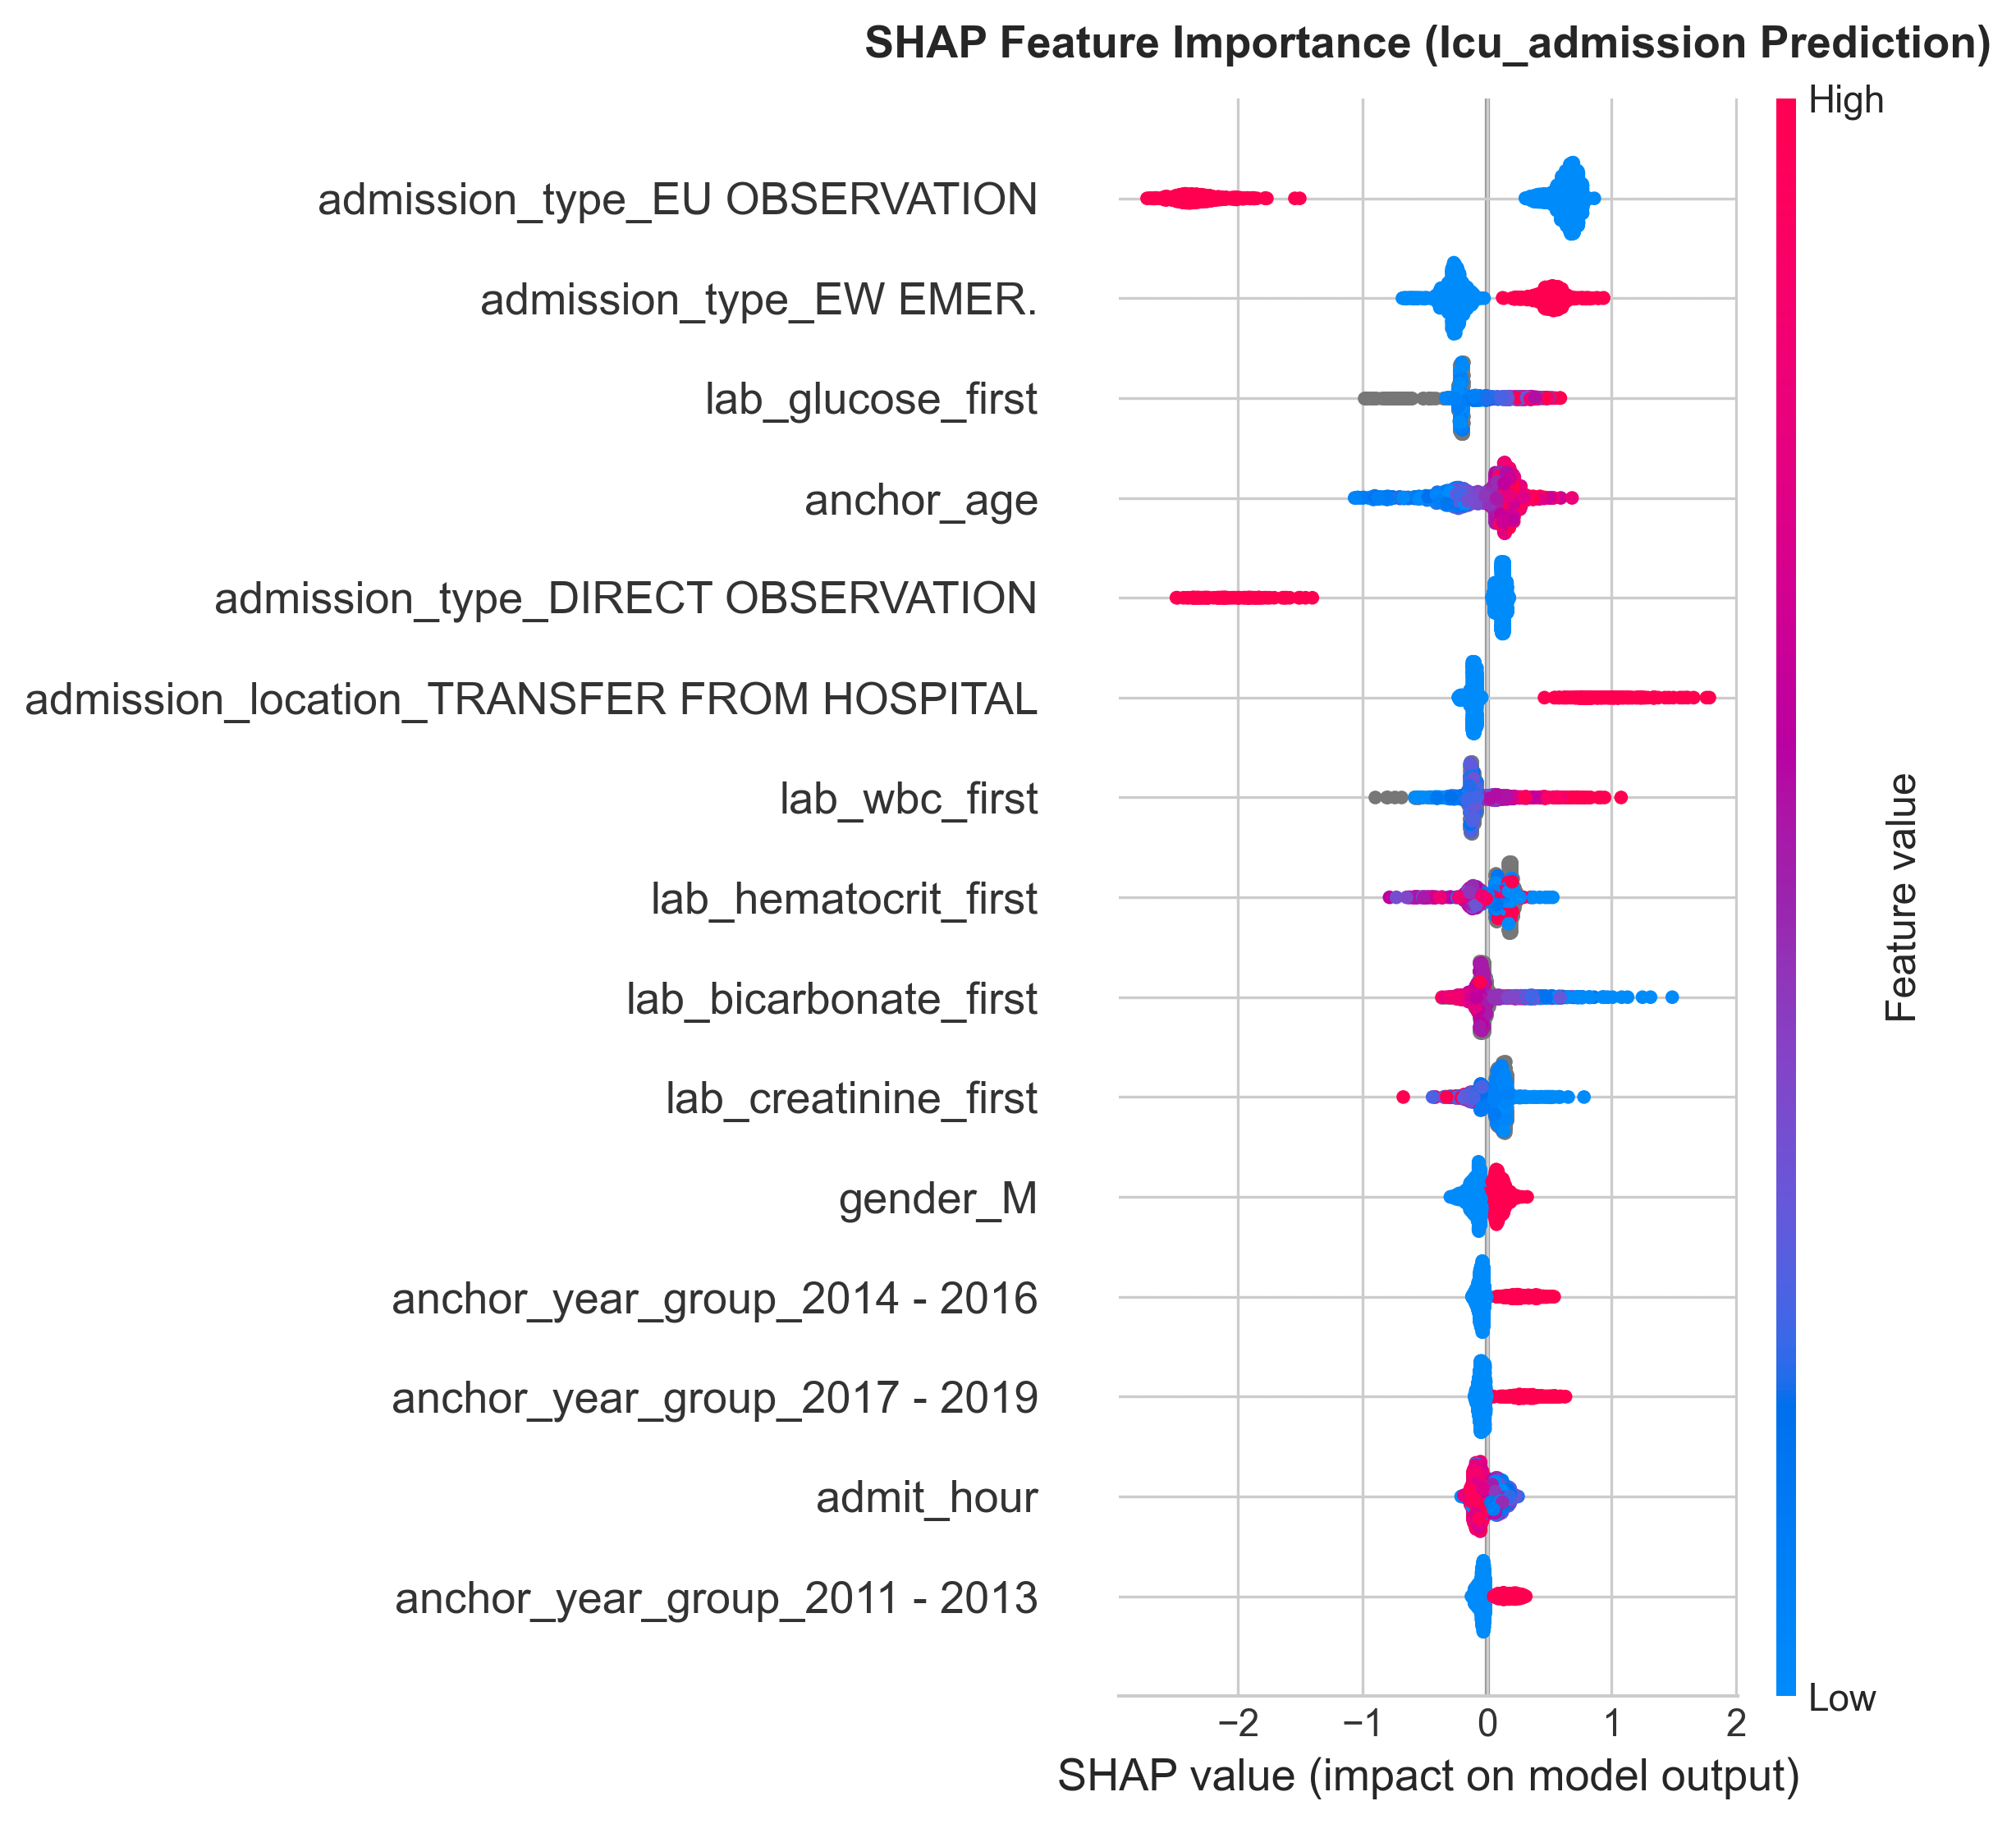

In [6]:
shap_sum_path = Path('../reports/figures/icu_admission_shap_summary.png')

if shap_sum_path.exists():
    print('--- SHAP Feature Summary Plot ---')
    display.display(display.Image(filename=str(shap_sum_path)))
else:
    print('SHAP summary image not found.')